In [ ]:
import sys
from pathlib import Path
sys.path.insert(0, str(next(d for d in [Path.cwd(), *Path.cwd().parents] if (d / "src").is_dir())))
from src.paths import ROOT


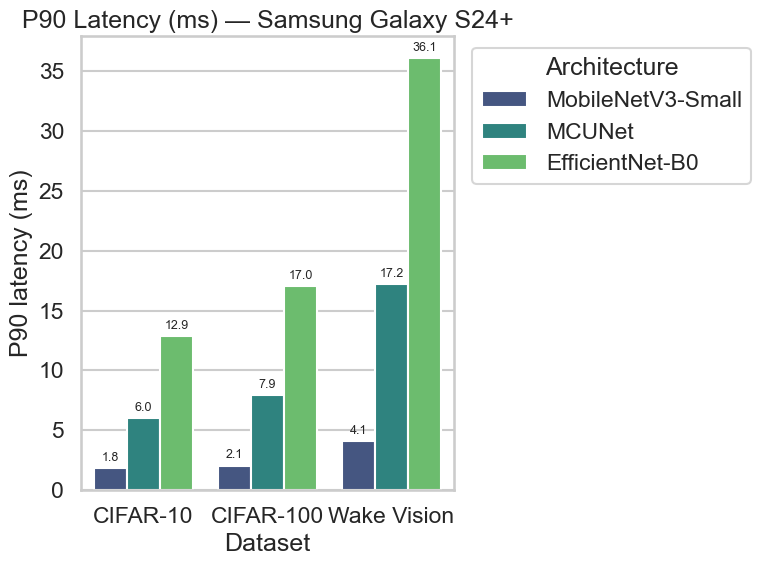

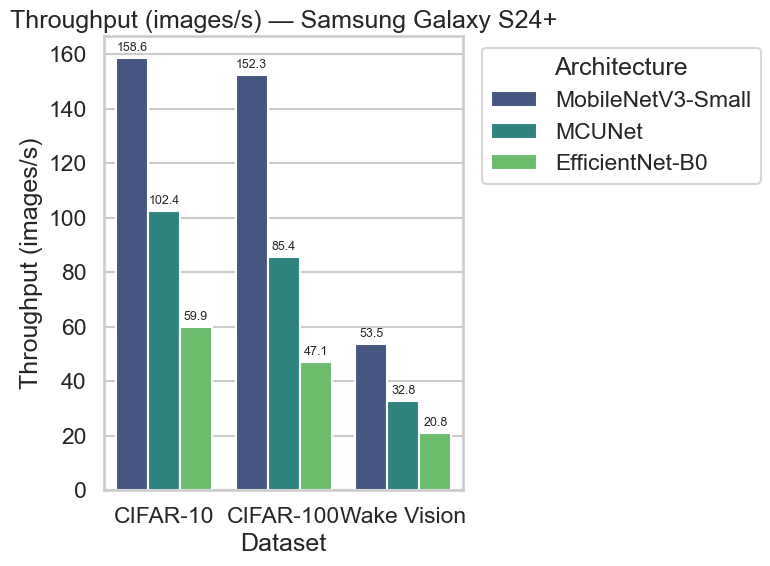

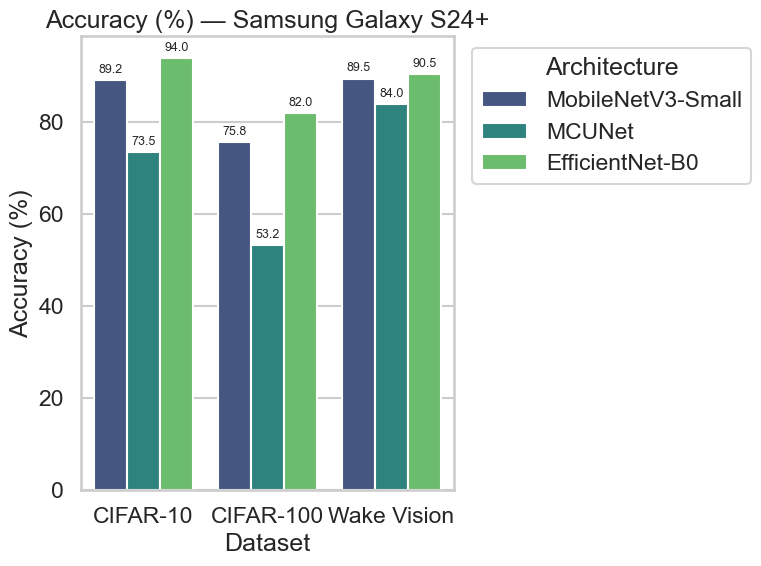

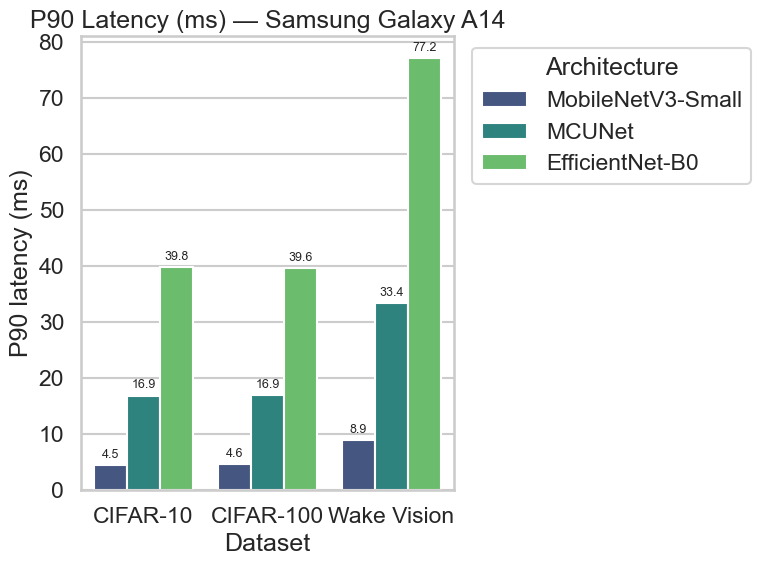

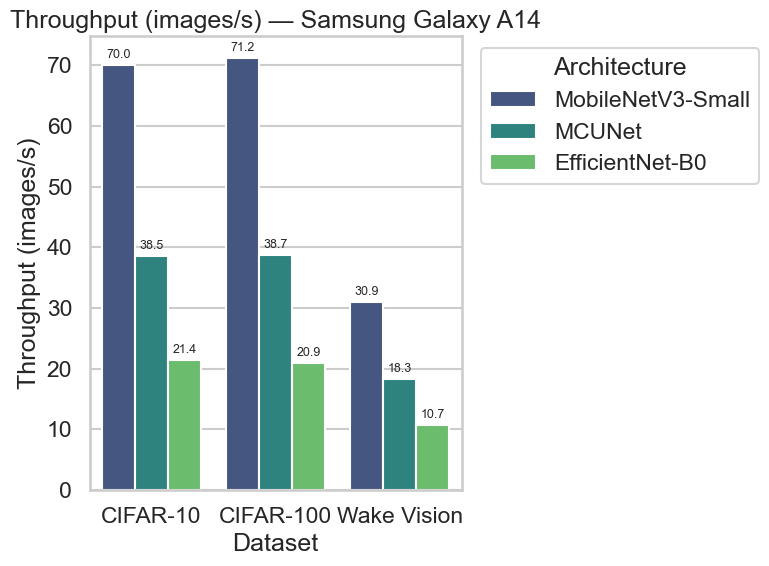

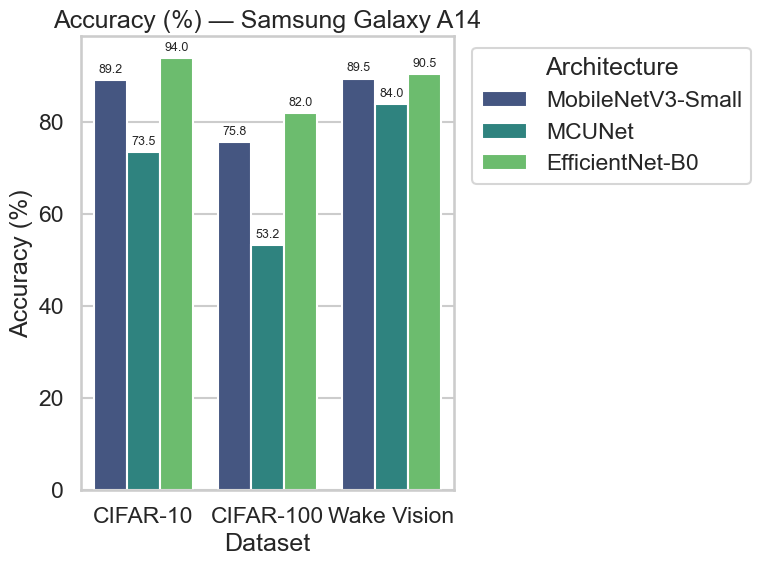

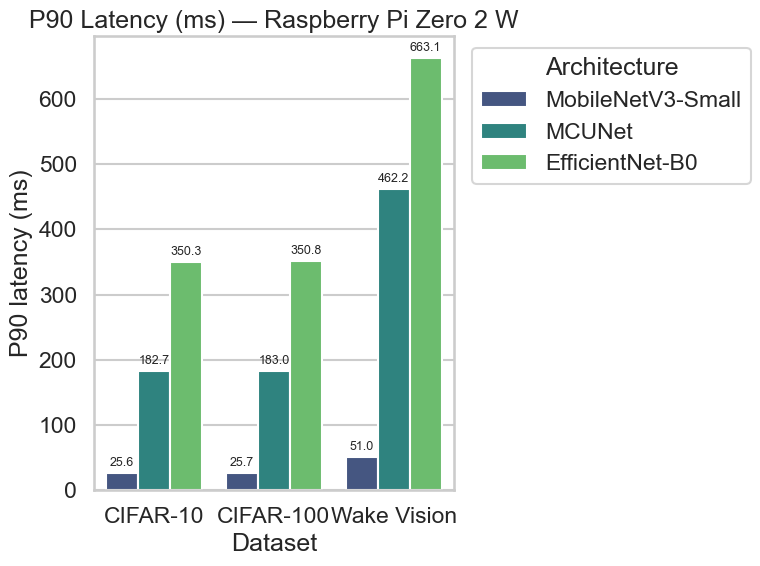

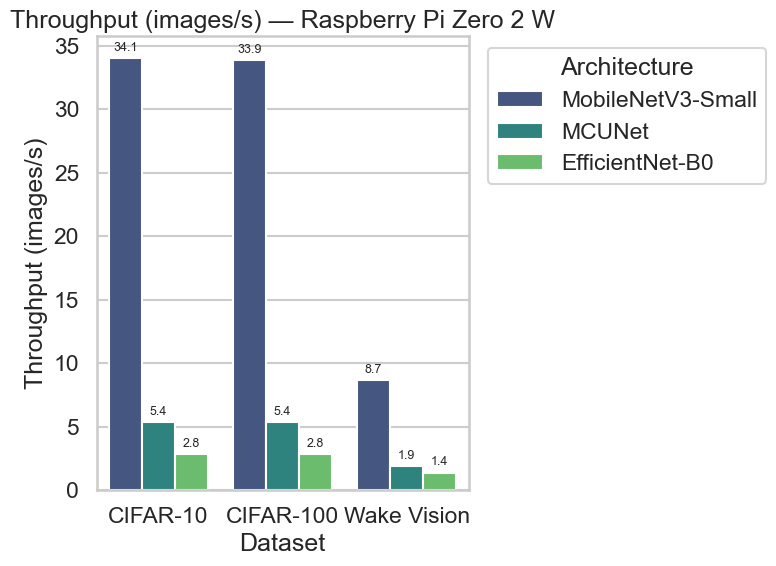

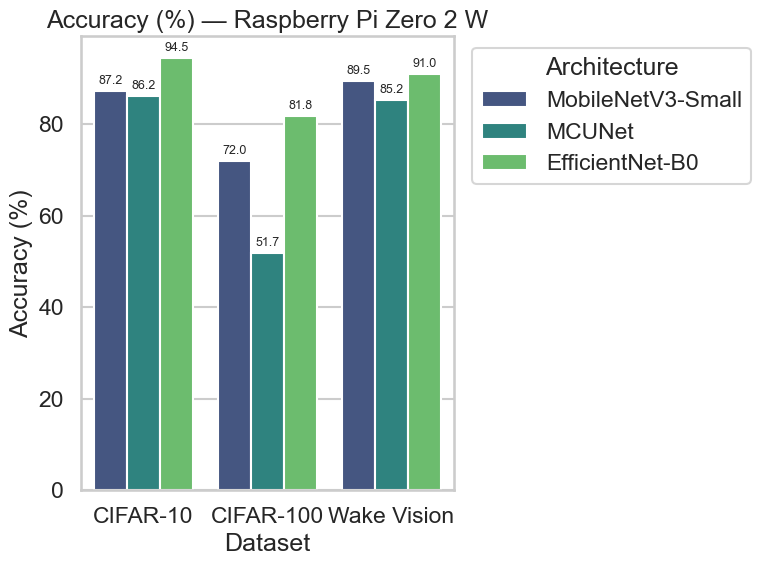

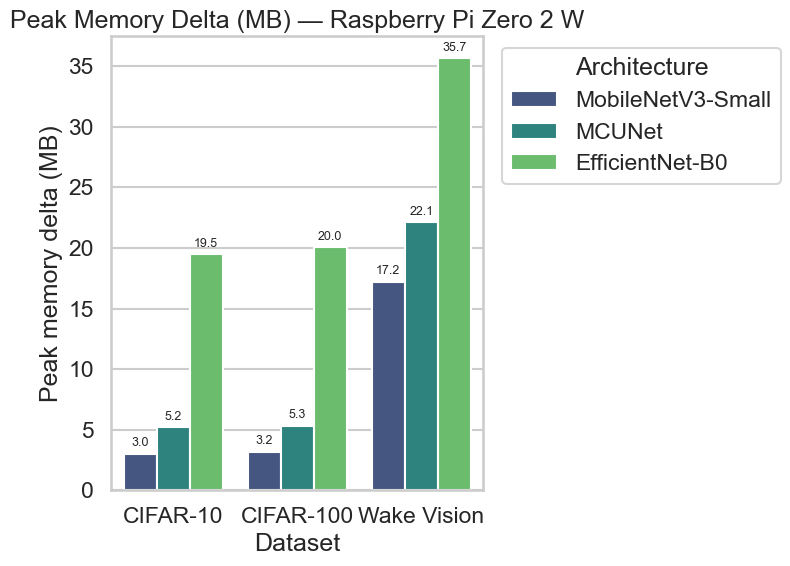

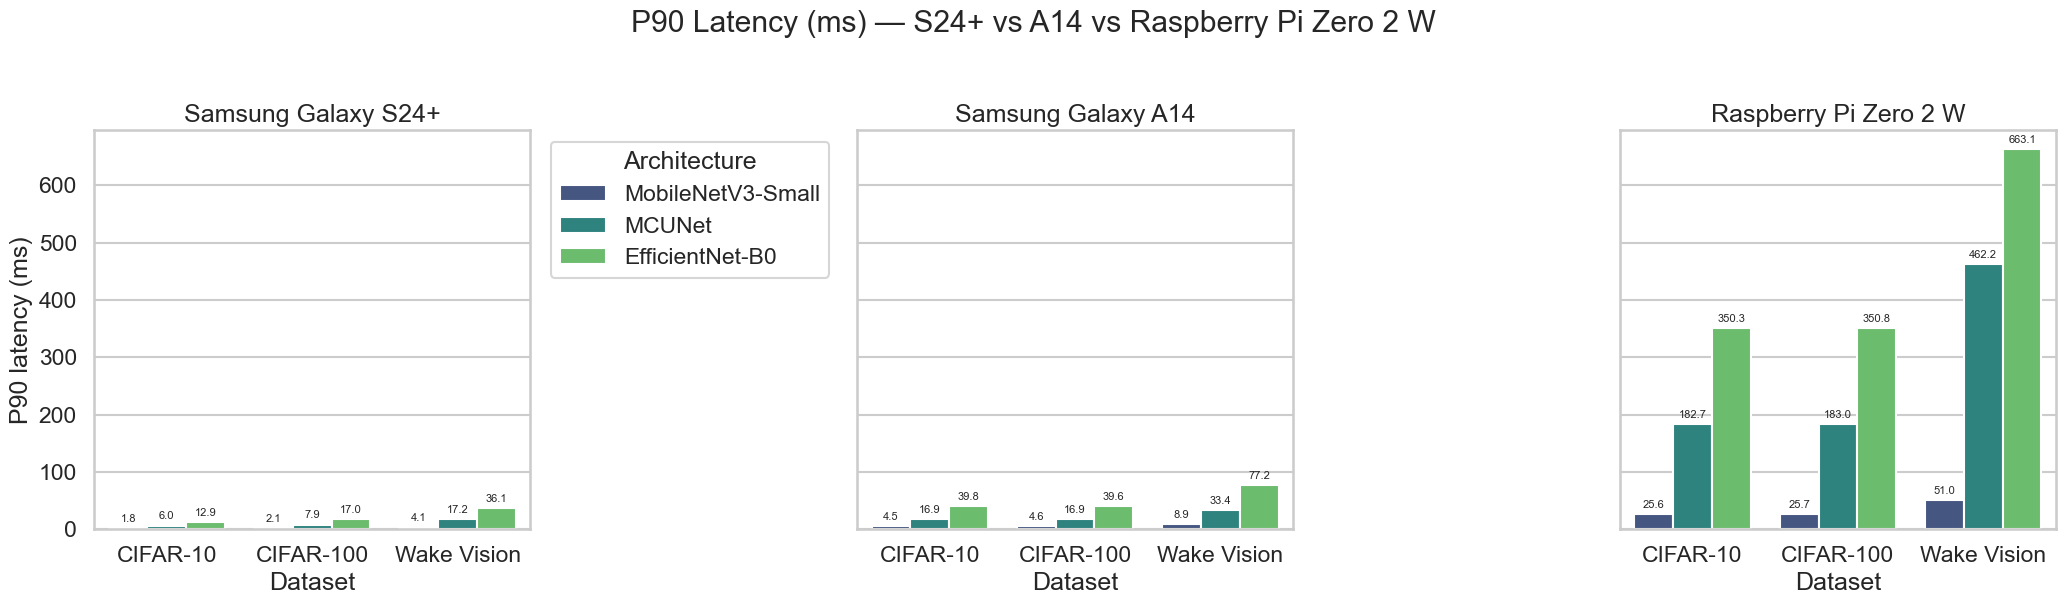

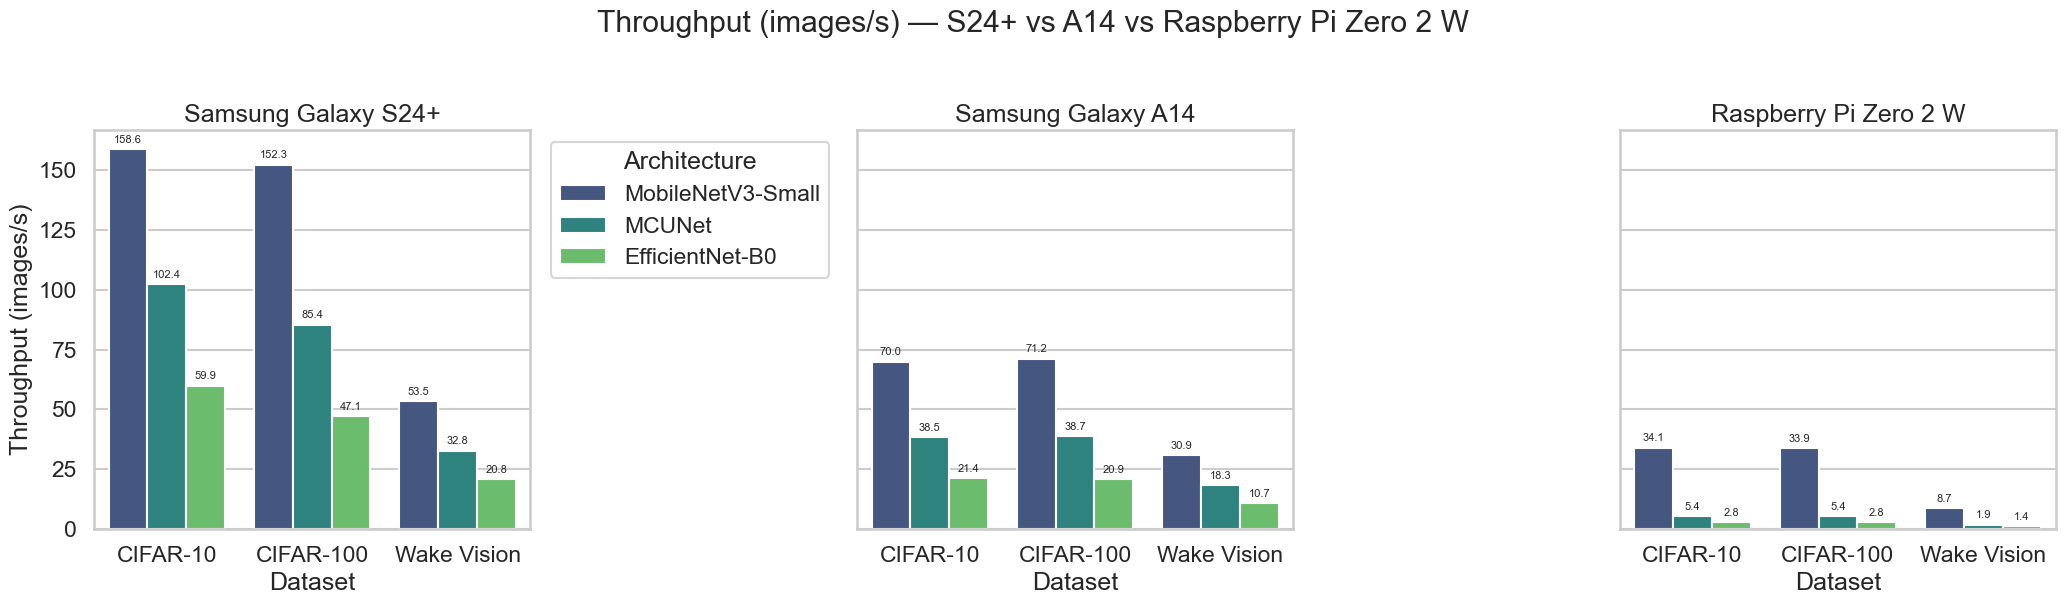

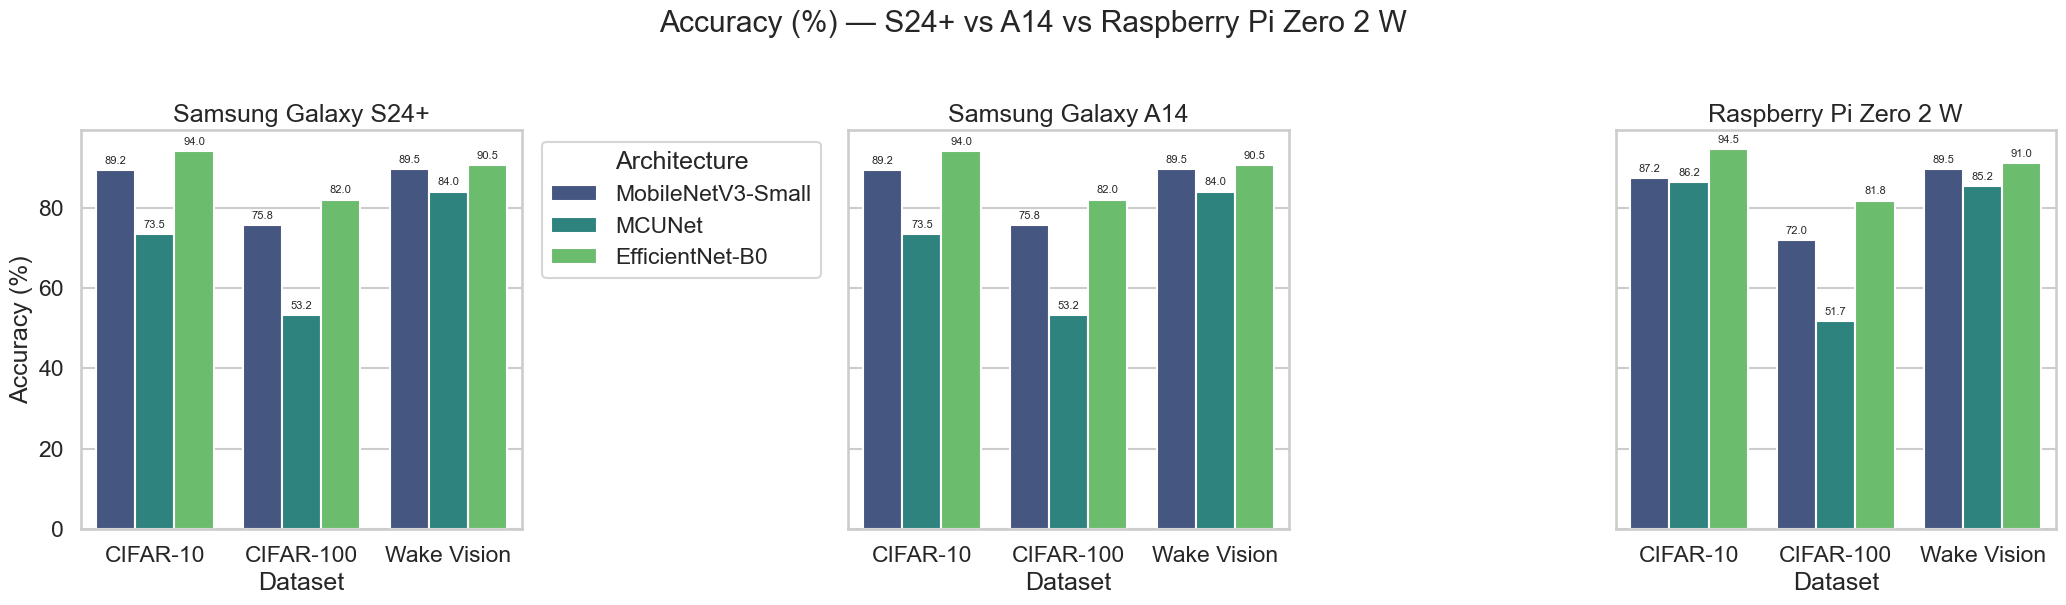

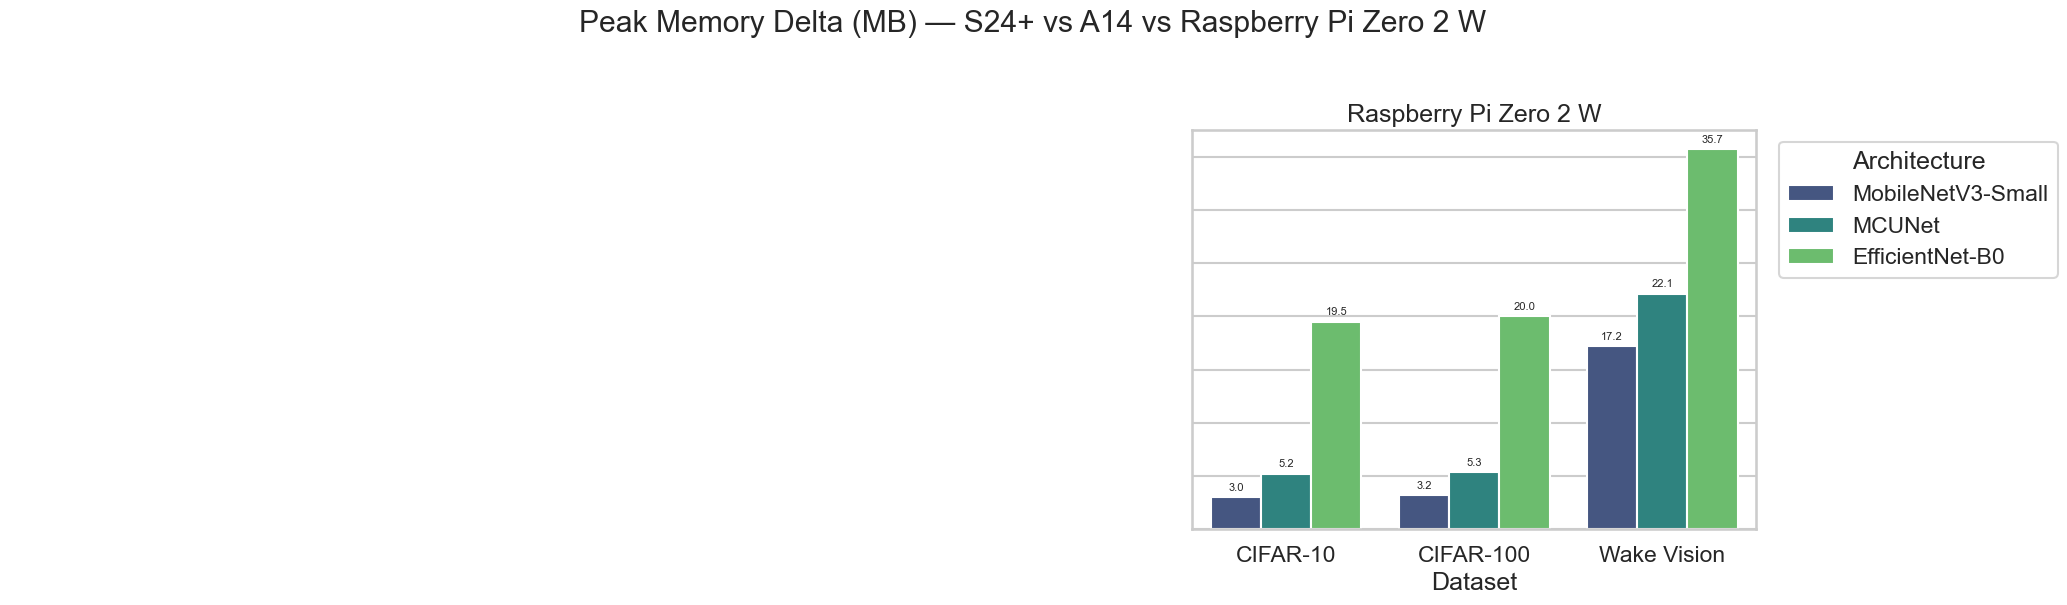

,Dataset,Model,Accuracy (%),Average Latency (ms),P90 Latency (ms),Throughput (images/s),Memory After (MB),Memory Before (MB),Memory Delta (MB),Peak Memory After (MB),Peak Memory Before (MB),Peak Memory Delta (MB),Platform
0,CIFAR-10,MobileNetV3-Small,89.25,1.774322,1.830747,158.626365,NaN,NaN,NaN,NaN,NaN,NaN,Samsung Galaxy S24+
1,CIFAR-10,MCUNet,73.50,5.918342,5.984110,102.367271,NaN,NaN,NaN,NaN,NaN,NaN,Samsung Galaxy S24+
2,CIFAR-10,EfficientNet-B0,94.00,12.780620,12.867578,59.943583,NaN,NaN,NaN,NaN,NaN,NaN,Samsung Galaxy S24+
3,CIFAR-100,MobileNetV3-Small,75.75,1.860038,2.051309,152.261228,NaN,NaN,NaN,NaN,NaN,NaN,Samsung Galaxy S24+
4,CIFAR-100,MCUNet,53.25,7.121465,7.933992,85.435672,NaN,NaN,NaN,NaN,NaN,NaN,Samsung Galaxy S24+
5,CIFAR-100,EfficientNet-B0,82.00,16.303564,17.041120,47.078422,NaN,NaN,NaN,NaN,NaN,NaN,Samsung Galaxy S24+
6,Wake Vision,MobileNetV3-Small,89.50,3.971122,4.072613,53.516697,NaN,NaN,NaN,NaN,NaN,NaN,Samsung Galaxy S24+
7,Wake Vision,MCUNet,84.00,16.078680,17.181348,32.812659,NaN,NaN,NaN,NaN,NaN,NaN,Samsung Galaxy S24+
8,Wake Vision,EfficientNet-B0,90.50,33.557128,36.113488,20.804277,NaN,NaN,NaN,NaN,NaN,NaN,Samsung Galaxy S24+
9,CIFAR-10,MobileNetV3-Small,89.25,4.426914,4.529466,69.951399,NaN,NaN,NaN,NaN,NaN,NaN,Samsung Galaxy A14


In [ ]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================
# Path definitions and helper functions
# =========================================================
android_runs = {
    "Samsung Galaxy S24+": [
        ROOT / "results/s24p_metrics_cifar10_cpu_400imgs_1775267671116.json",
        ROOT / "results/s24p_metrics_cifar100_cpu_400imgs_1775267691899.json",
        ROOT / "results/s24p_metrics_wakevision_cpu_400imgs_1775267738764.json",
    ],
    "Samsung Galaxy A14": [
        ROOT / "results/a14_metrics_cifar10_cpu_400imgs_1775245845979.json",
        ROOT / "results/a14_metrics_cifar100_cpu_400imgs_1775245894612.json",
        ROOT / "results/a14_metrics_wakevision_cpu_400imgs_1775245982177.json",
    ],
}

PI_MERGED_FILE = ROOT / "results/raspberry/results/results_merged.json"

DATASET_DISPLAY = {
    "cifar10": "CIFAR-10",
    "cifar100": "CIFAR-100",
    "wakevision": "Wake Vision",
    "CIFAR-10": "CIFAR-10",
    "CIFAR-100": "CIFAR-100",
    "Wake Vision": "Wake Vision",
}

MODEL_DISPLAY = {
    "efficientnetb0": "EfficientNet-B0",
    "efficientnet_b0": "EfficientNet-B0",
    "efficientnet-b0": "EfficientNet-B0",
    "efficientnet": "EfficientNet-B0",
    "lcnn": "MCUNet",
    "mcunet": "MCUNet",
    "mobilenetv3small": "MobileNetV3-Small",
    "mobilenetv3_small": "MobileNetV3-Small",
    "mobilenetv3-small": "MobileNetV3-Small",
    "mobilenet": "MobileNetV3-Small",
}

def normalize_dataset_name(name: str) -> str:
    key = str(name).strip()
    return DATASET_DISPLAY.get(key, DATASET_DISPLAY.get(key.lower(), key))

def normalize_model_name(name: str) -> str:
    key = str(name).strip()
    normalized = key.lower().replace(" ", "")
    return MODEL_DISPLAY.get(key, MODEL_DISPLAY.get(normalized, name))

def base_model_from_android(name: str) -> str:
    n = str(name).lower()
    if "efficientnet" in n:
        return "EfficientNet-B0"
    if "mcunet" in n:
        return "MCUNet"
    if "mobilenet" in n:
        return "MobileNetV3-Small"
    return name

def bytes_to_mb(x):
    if x is None:
        return None
    return float(x) / (1024 ** 2)

def load_pi_merged_report(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        report = json.load(f)
    datasets = report.get("datasets", report)

    for ds_key, ds_block in datasets.items():
        ds_name = normalize_dataset_name(ds_key)
        models = ds_block.get("models", {})

        for model_key, m in models.items():
            model_name = normalize_model_name(m.get("model", model_key))

            p90 = float(m["latency_ms"]["p90"])
            avg = float(m["latency_ms"]["avg"])
            throughput = float(m.get("throughput_imgs", m.get("throughput_img_s")))
            acc = float(m["accuracy"]) * 100.0

            mem_after = m.get("memoryUsageAfterBytes")
            mem_before = m.get("memoryUsageBeforeBytes")
            mem_delta = m.get("memoryUsageDeltaBytes")

            peak_after = m.get("peakMemoryUsageAfterBytes")
            peak_before = m.get("peakMemoryUsageBeforeBytes")
            peak_delta = m.get("peakMemoryUsageDeltaBytes")

            rows.append(
                {
                    "Dataset": ds_name,
                    "Model": model_name,
                    "Accuracy (%)": acc,
                    "Average Latency (ms)": avg,
                    "P90 Latency (ms)": p90,
                    "Throughput (images/s)": throughput,
                    "Memory After (MB)": bytes_to_mb(mem_after),
                    "Memory Before (MB)": bytes_to_mb(mem_before),
                    "Memory Delta (MB)": bytes_to_mb(mem_delta),
                    "Peak Memory After (MB)": bytes_to_mb(peak_after),
                    "Peak Memory Before (MB)": bytes_to_mb(peak_before),
                    "Peak Memory Delta (MB)": bytes_to_mb(peak_delta),
                    "Platform": "Raspberry Pi Zero 2 W",
                }
            )
    return rows

# =========================================================
# Load data
# =========================================================
data = []

# Android
for platform_name, files in android_runs.items():
    for file in files:
        if not file.exists():
            print(f"Note: Android file not found (skipped): {file}")
            continue

        with open(file, "r", encoding="utf-8") as f:
            content = json.load(f)

        for model in content.get("models", []):
            data.append(
                {
                    "Dataset": normalize_dataset_name(model["datasetName"]),
                    "Model": base_model_from_android(model["modelName"]),
                    "Accuracy (%)": float(model["accuracy"]) * 100,
                    "Average Latency (ms)": float(model["avgLatencyMs"]),
                    "P90 Latency (ms)": float(model["p90LatencyMs"]),
                    "Throughput (images/s)": float(model["throughputImagesPerSecond"]),
                    "Memory After (MB)": float(model["memoryUsageMB"]) if "memoryUsageMB" in model else None,
                    "Memory Before (MB)": None,
                    "Memory Delta (MB)": None,
                    "Peak Memory After (MB)": None,
                    "Peak Memory Before (MB)": None,
                    "Peak Memory Delta (MB)": None,
                    "Platform": platform_name,
                }
            )

# Raspberry Pi
if PI_MERGED_FILE.exists():
    data.extend(load_pi_merged_report(PI_MERGED_FILE))
else:
    print(f"Note: Pi merged file not found (skipped): {PI_MERGED_FILE}")

df = pd.DataFrame(data)

# =========================================================
# Ordering
# =========================================================
dataset_order = ["CIFAR-10", "CIFAR-100", "Wake Vision"]
model_order = ["MobileNetV3-Small", "MCUNet", "EfficientNet-B0"]
platform_order = ["Samsung Galaxy S24+", "Samsung Galaxy A14", "Raspberry Pi Zero 2 W"]

df["Dataset"] = pd.Categorical(df["Dataset"], categories=dataset_order, ordered=True)
df["Model"] = pd.Categorical(df["Model"], categories=model_order, ordered=True)
df["Platform"] = pd.Categorical(df["Platform"], categories=platform_order, ordered=True)

df = df.sort_values(["Platform", "Dataset", "Model"]).reset_index(drop=True)

# =========================================================
# Visual settings
# =========================================================
sns.set_theme(style="whitegrid", context="talk")
palette = "viridis"

metrics = [
    ("P90 Latency (ms)", "P90 latency (ms)"),
    ("Throughput (images/s)", "Throughput (images/s)"),
    ("Accuracy (%)", "Accuracy (%)"),
    ("Peak Memory Delta (MB)", "Peak memory delta (MB)"),
]

platforms = [p for p in platform_order if p in set(df["Platform"].dropna())]

# =========================================================
# 1) Individual plots per platform
# =========================================================
for platform in platforms:
    sub_df = df[df["Platform"] == platform]

    for col, ylabel in metrics:
        plot_df = sub_df.dropna(subset=[col])
        if plot_df.empty:
            continue

        plt.figure(figsize=(8, 6))
        ax = sns.barplot(data=plot_df, x="Dataset", y=col, hue="Model", palette=palette)
        ax.set_title(f"{col} — {platform}")
        ax.set_xlabel("Dataset")
        ax.set_ylabel(ylabel)

        for container in ax.containers:
            ax.bar_label(container, fmt="%.1f", padding=3, fontsize=9)

        handles, labels = ax.get_legend_handles_labels()
        if handles:
            ax.legend(handles, labels, title="Architecture", bbox_to_anchor=(1.02, 1), loc="upper left")

        plt.tight_layout()
        plt.show()

# =========================================================
# 2) Compartive plots with all platforms together
# =========================================================
for col, ylabel in metrics:
    n_p = max(1, len(platforms))
    fig_w = 7 * n_p
    fig, axes = plt.subplots(1, n_p, figsize=(fig_w, 6), sharey=True)

    if n_p == 1:
        axes = [axes]

    used_axes = []
    for ax, platform in zip(axes, platforms):
        sub = df[(df["Platform"] == platform) & (df[col].notna())]
        if sub.empty:
            ax.axis("off")
            continue

        sns.barplot(data=sub, x="Dataset", y=col, hue="Model", palette=palette, ax=ax)
        ax.set_title(platform)
        ax.set_xlabel("Dataset")
        ax.set_ylabel(ylabel)

        for container in ax.containers:
            ax.bar_label(container, fmt="%.1f", padding=3, fontsize=8)

        used_axes.append(ax)

    if used_axes:
        handles, labels = used_axes[0].get_legend_handles_labels()
        for ax in used_axes[1:]:
            if ax.legend_:
                ax.legend_.remove()
        if handles:
            used_axes[0].legend(handles, labels, title="Architecture", bbox_to_anchor=(1.02, 1), loc="upper left")

    fig.suptitle(f"{col} — S24+ vs A14 vs Raspberry Pi Zero 2 W", y=1.02)
    plt.tight_layout()
    plt.show()

# =========================================================
# 3) Final table with all data
# =========================================================
display(df)

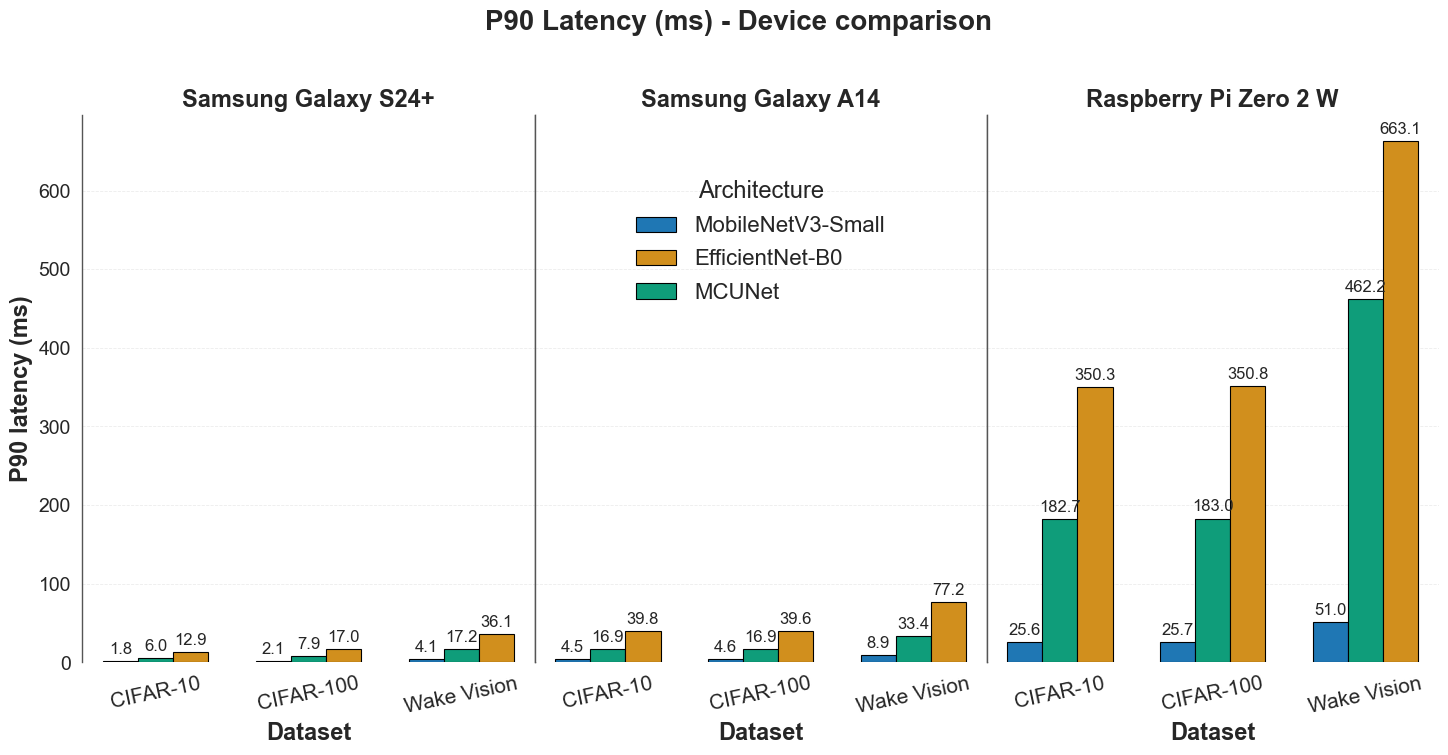

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.patches import Patch

# Base style
sns.set_theme(style="white", context="paper")

p90_col = "P90 Latency (ms)"
p90_df = df[df[p90_col].notna()].copy()

plot_palette = {
    "MobileNetV3-Small": "#1f77b4",
    "EfficientNet-B0": "#d18f1d",
    "MCUNet": "#0f9d7a",
}

comparison_platforms = [
    p for p in ["Samsung Galaxy S24+", "Samsung Galaxy A14", "Raspberry Pi Zero 2 W"]
    if p in set(p90_df["Platform"].dropna())
]

platform_title_map = {
    "Samsung Galaxy S24+": "Samsung Galaxy S24+",
    "Samsung Galaxy A14": "Samsung Galaxy A14",
    "Raspberry Pi Zero 2 W": "Raspberry Pi Zero 2 W",
}

dataset_order = ["CIFAR-10", "CIFAR-100", "Wake Vision"]

fig, axes = plt.subplots(1, len(comparison_platforms), figsize=(17.5, 7.5), sharey=True)

if len(comparison_platforms) == 1:
    axes = [axes]

fig.patch.set_facecolor("white")

bar_width = 0.23
offsets = [-bar_width, 0, bar_width]

for i, (ax, platform) in enumerate(zip(axes, comparison_platforms)):
    sub = p90_df[p90_df["Platform"] == platform].copy()
    x = np.arange(len(dataset_order))

    for j, dataset in enumerate(dataset_order):
        ds = sub[sub["Dataset"] == dataset].copy()

        if ds.empty:
            continue

        # Sort models by P90 latency within each dataset (lowest to highest)
        ds = ds.sort_values(by=p90_col, ascending=True).reset_index(drop=True)

        for k, (_, row) in enumerate(ds.iterrows()):
            xpos = x[j] + offsets[k]
            height = row[p90_col]
            model = row["Model"]

            bars = ax.bar(
                xpos,
                height,
                width=bar_width,
                color=plot_palette[model],
                edgecolor="black",
                linewidth=0.8
            )

            ax.bar_label(bars, fmt="%.1f", padding=3, fontsize=12)

    ax.set_facecolor("white")
    ax.set_title(platform_title_map[platform], fontsize=17, fontweight="bold")
    ax.set_xlabel("Dataset", fontsize=17, fontweight="bold")
    ax.set_ylabel("P90 latency (ms)" if i == 0 else "", fontsize=17, fontweight="bold")

    ax.set_xticks(x)
    ax.set_xticklabels(dataset_order, rotation=12, fontsize=15)
    ax.tick_params(axis="y", labelsize=14)

    ax.grid(axis="y", color="#d9d9d9", linestyle="--", linewidth=0.6, alpha=0.5)
    ax.grid(axis="x", visible=False)

    ax.spines["top"].set_visible(False)
    ax.spines["bottom"].set_visible(False)

    ax.spines["left"].set_visible(True)
    ax.spines["left"].set_color("#555555")
    ax.spines["left"].set_linewidth(1.0)

    ax.spines["right"].set_visible(i < len(axes) - 1)
    ax.spines["right"].set_color("#555555")
    ax.spines["right"].set_linewidth(1.0)

legend_handles = [
    Patch(facecolor=plot_palette["MobileNetV3-Small"], edgecolor="black", label="MobileNetV3-Small"),
    Patch(facecolor=plot_palette["EfficientNet-B0"], edgecolor="black", label="EfficientNet-B0"),
    Patch(facecolor=plot_palette["MCUNet"], edgecolor="black", label="MCUNet"),
]

mid_ax = axes[1] if len(axes) > 1 else axes[0]
mid_ax.legend(
    handles=legend_handles,
    title="Architecture",
    title_fontsize=17,
    fontsize=16,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.91),
    frameon=False,
    ncol=1,
    handlelength=1.8,
    handletextpad=0.8,
    labelspacing=0.6,
    borderaxespad=0.3
)

fig.suptitle(
    "P90 Latency (ms) - Device comparison",
    y=0.98,
    fontsize=20,
    fontweight="bold"
)

fig.subplots_adjust(top=0.84, wspace=0.00)

outdir = ROOT / "figures"
fig.savefig(outdir / "p90_latency_device_comparison.pdf", dpi=300, bbox_inches="tight")
plt.show()

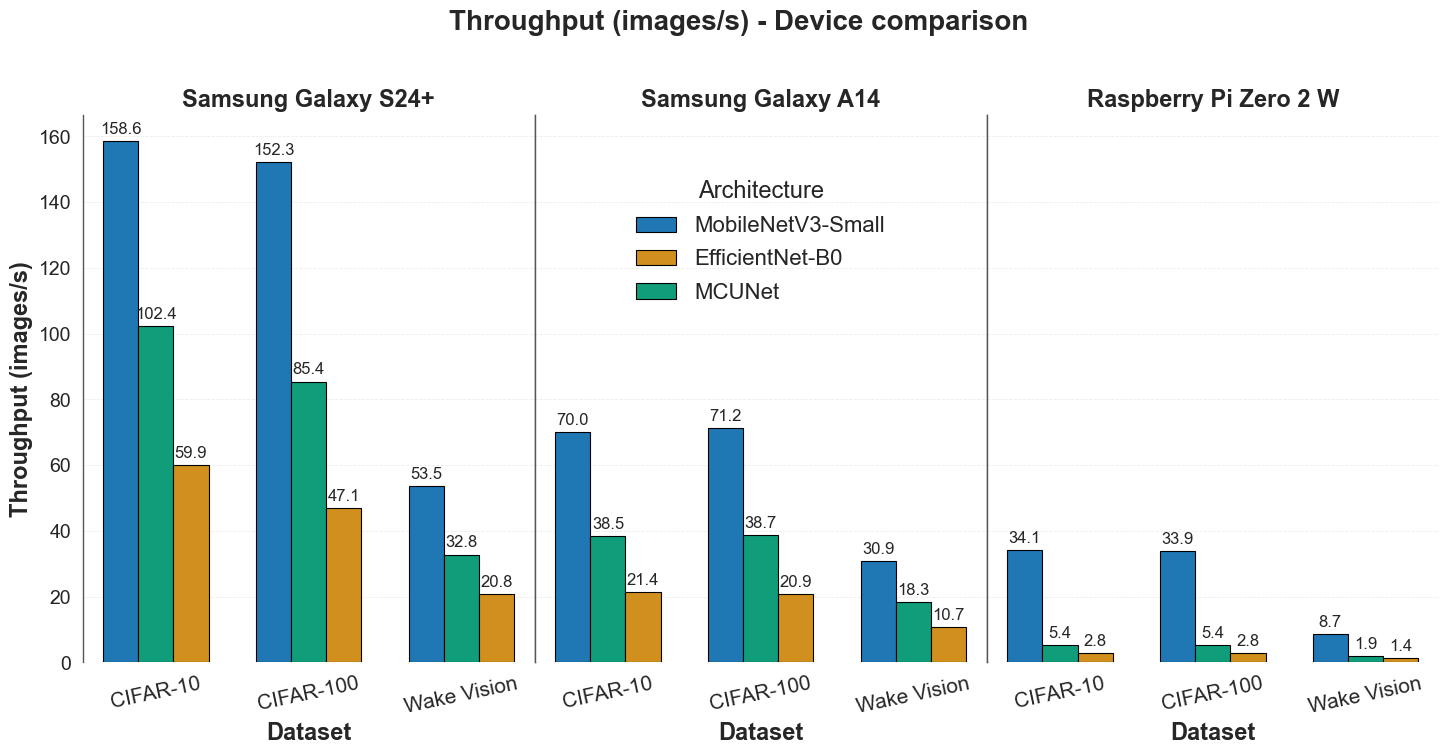

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.patches import Patch

# Base style
sns.set_theme(style="white", context="paper")

throughput_col = "Throughput (images/s)"
throughput_df = df[df[throughput_col].notna()].copy()

plot_palette = {
    "MobileNetV3-Small": "#1f77b4",
    "EfficientNet-B0": "#d18f1d",
    "MCUNet": "#0f9d7a",
}

comparison_platforms = [
    p for p in ["Samsung Galaxy S24+", "Samsung Galaxy A14", "Raspberry Pi Zero 2 W"]
    if p in set(throughput_df["Platform"].dropna())
]

platform_title_map = {
    "Samsung Galaxy S24+": "Samsung Galaxy S24+",
    "Samsung Galaxy A14": "Samsung Galaxy A14",
    "Raspberry Pi Zero 2 W": "Raspberry Pi Zero 2 W"
}

dataset_order = ["CIFAR-10", "CIFAR-100", "Wake Vision"]

fig, axes = plt.subplots(1, len(comparison_platforms), figsize=(17.5, 7.5), sharey=True)

if len(comparison_platforms) == 1:
    axes = [axes]

fig.patch.set_facecolor("white")

bar_width = 0.23
offsets = [-bar_width, 0, bar_width]

for i, (ax, platform) in enumerate(zip(axes, comparison_platforms)):
    sub = throughput_df[throughput_df["Platform"] == platform].copy()
    x = np.arange(len(dataset_order))

    for j, dataset in enumerate(dataset_order):
        ds = sub[sub["Dataset"] == dataset].copy()

        if ds.empty:
            continue

        # Ordena os modelos dentro de cada dataset: maior throughput -> menor throughput
        ds = ds.sort_values(by=throughput_col, ascending=False).reset_index(drop=True)

        for k, (_, row) in enumerate(ds.iterrows()):
            xpos = x[j] + offsets[k]
            height = row[throughput_col]
            model = row["Model"]

            bars = ax.bar(
                xpos,
                height,
                width=bar_width,
                color=plot_palette[model],
                edgecolor="black",
                linewidth=0.8
            )

            ax.bar_label(bars, fmt="%.1f", padding=3, fontsize=12)

    ax.set_facecolor("white")
    ax.set_title(platform_title_map[platform], fontsize=17, fontweight="bold")
    ax.set_xlabel("Dataset", fontsize=17, fontweight="bold")
    ax.set_ylabel("Throughput (images/s)" if i == 0 else "", fontsize=17, fontweight="bold")

    ax.set_xticks(x)
    ax.set_xticklabels(dataset_order, rotation=12, fontsize=15)
    ax.tick_params(axis="y", labelsize=14)

    ax.grid(axis="y", color="#d9d9d9", linestyle="--", linewidth=0.6, alpha=0.5)
    ax.grid(axis="x", visible=False)

    ax.spines["top"].set_visible(False)
    ax.spines["bottom"].set_visible(False)

    ax.spines["left"].set_visible(True)
    ax.spines["left"].set_color("#555555")
    ax.spines["left"].set_linewidth(1.0)

    ax.spines["right"].set_visible(i < len(axes) - 1)
    ax.spines["right"].set_color("#555555")
    ax.spines["right"].set_linewidth(1.0)

legend_handles = [
    Patch(facecolor=plot_palette["MobileNetV3-Small"], edgecolor="black", label="MobileNetV3-Small"),
    Patch(facecolor=plot_palette["EfficientNet-B0"], edgecolor="black", label="EfficientNet-B0"),
    Patch(facecolor=plot_palette["MCUNet"], edgecolor="black", label="MCUNet"),
]

mid_ax = axes[1] if len(axes) > 1 else axes[0]
mid_ax.legend(
    handles=legend_handles,
    title="Architecture",
    title_fontsize=17,
    fontsize=16,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.91),
    frameon=False,
    ncol=1,
    handlelength=1.8,
    handletextpad=0.8,
    labelspacing=0.6,
    borderaxespad=0.3
)

fig.suptitle(
    "Throughput (images/s) - Device comparison",
    y=0.98,
    fontsize=20,
    fontweight="bold"
)

fig.subplots_adjust(top=0.84, wspace=0.00)

outdir = ROOT / "figures"
fig.savefig(outdir / "throughput_device_comparison.pdf", dpi=300, bbox_inches="tight")
plt.show()